# Future-token vs. random-token reconstruction, window 0 (TR 0-200)

Two masking regimes are compared, restricted to a single window (`WINDOW_INDEX=0`,
TRs 0-199 -- no averaging across the 3 sliding windows, since we're only looking at
window 0 anyway):

1. **Future**: for every region, mask that region's own *last* 20-TR patch
   (patch index `num_patches - 1`) and ask the model to predict it.
2. **Random**: for every region, mask one *randomly chosen* 20-TR patch (uniform over
   all `num_patches` patch positions, independently per region) and predict it.

Both conditions mask exactly **one 20-TR patch per region** -- `num_regions` tokens
out of `seq_len = num_regions * num_patches` total, i.e. `mask_ratio = 1 / num_patches`
-- so the two conditions are matched in how much of the input the model gets to see
(same count, same per-region granularity) and differ only in *where in time* the
masked patch sits. This is a single forward pass per condition (not the deterministic
full-coverage sweep in `reconstruction_validation.ipynb`), since we only need
predictions for these specific, fixed token positions.

For each region, one Pearson r is computed between the predicted 20-TR patch and
`raw_ts` at the same TR span (no window-averaging, no full-signal correlation --
just the masked patch itself, since that's the only part of the output the encoder
never saw). The result is a per-region r distribution for each condition, compared
via overlaid histograms and a paired Wilcoxon test (same regions, same subjects,
only the patch location differs).

**Note on raw vs. scaled ground truth**: `preprocess_subject_data` applies a
per-region median/IQR affine transform before feeding data to the model. Pearson's
r is invariant to affine transforms of either variable independently, so correlating
the model's (scaled-space) prediction against `raw_ts` gives the *same* r as
correlating it against the scaled input -- using `raw_ts` directly (as in
`fc_attention_correlation.ipynb`) is just simpler, not a different metric.

Reuses this repo's `run_model.py` loaders (`load_brainlm_model`,
`load_spatial_coordinates`, `preprocess_subject_data`) and the `old_13M` checkpoint,
same as `reconstruction_validation.ipynb`.

In [1]:
import os
import sys
import csv

# Cap CPU threads BEFORE importing heavy libraries (same convention as run_model.py)
MAX_CPU_THREADS = 4
os.environ["OMP_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(MAX_CPU_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(MAX_CPU_THREADS)

import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import stats

torch.set_num_threads(MAX_CPU_THREADS)

# validation/ is one level below the repo root, unlike attention_by_window.ipynb
sys.path.insert(0, os.path.abspath(".."))
from run_model import load_brainlm_model, load_spatial_coordinates, preprocess_subject_data

# run_model imports visualize_attention, which calls matplotlib.use("Agg") for
# headless script runs -- re-enable the inline backend for this notebook.
get_ipython().run_line_magic("matplotlib", "inline")

In [2]:
# --- Config ---
INPUT_H5 = "../data/input/fmri_timeseries_subset_100.h5"
COORDS = "../data/input/toolkit/atlases/A424_Coordinates.dat"
HF_REPO = "vandijklab/brainlm"
SUBFOLDER = "old_13M"

SUBJECT_INDEX = 0     # Sub_0000, single-subject deep dive
WINDOW_INDEX = 0       # TRs 0-200 only, per the notebook's scope
NUM_WINDOWS = 3         # must match preprocess_subject_data's slicing used elsewhere in the repo
WINDOW_SIZE = 200

RANDOM_SEED = 0
N_SUBJECTS_MULTI = 25   # multi-subject pooled section, below

N_EXAMPLES_PER_CONDITION = 3  # top-r regions shown in the visual sanity-check plot, per condition

FIGURES_DIR = "figures"
OUTPUTS_DIR = "outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model, config = load_brainlm_model(HF_REPO, SUBFOLDER)
model.to(device)
model.eval()

spatial_coords = load_spatial_coordinates(COORDS).to(device)  # [1, 424, 3]

num_regions = config.num_brain_voxels
patch_size = config.timepoint_patching_size
num_patches = WINDOW_SIZE // patch_size
seq_len = num_regions * num_patches
FUTURE_PATCH_IDX = num_patches - 1

# Exactly one masked patch per region, for both conditions -> mask_ratio = 1/num_patches,
# identical for "future" and "random" (same count, same per-region granularity).
MASK_RATIO = num_regions / seq_len
model.config.mask_ratio = MASK_RATIO

print(f"num_regions={num_regions}, num_patches={num_patches}, patch_size={patch_size}, seq_len={seq_len}")
print(f"mask_ratio={MASK_RATIO:.4f} (= {num_regions} masked tokens / {seq_len} total)")
print(f"future patch index (last): {FUTURE_PATCH_IDX} -> TRs [{FUTURE_PATCH_IDX * patch_size}, {(FUTURE_PATCH_IDX + 1) * patch_size})")

Device: cpu


/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/fmoss/miniforge3/envs/brainlm/lib/python3.10/site-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


loading weights file pytorch_model.bin from cache at /home/fmoss/.cache/huggingface/hub/models--vandijklab--brainlm/snapshots/4c54e0cccf920d9d6af7c647cb866fc19c60cf26/old_13M/pytorch_model.bin


All model checkpoint weights were used when initializing BrainLMForPretraining.



All the weights of BrainLMForPretraining were initialized from the model checkpoint at vandijklab/brainlm.
If your task is similar to the task the model of the checkpoint was trained on, you can already use BrainLMForPretraining for predictions without further training.


num_regions=424, num_patches=10, patch_size=20, seq_len=4240
mask_ratio=0.1000 (= 424 masked tokens / 4240 total)
future patch index (last): 9 -> TRs [180, 200)


## Helpers: exact-mask construction and per-patch correlation

`BrainLMEmbeddings.random_masking` (see `brainlm_mae/modeling_brainlm.py`) masks
whichever tokens end up in the *largest*-noise positions after
`torch.argsort(noise, dim=1)`, where the token count masked is
`seq_length * mask_ratio` (read from `model.config.mask_ratio`). `build_exact_mask_noise`
exploits this directly: draw ordinary `[0, 1)` noise for every token, then overwrite
the noise at exactly the token indices we want masked with `[1, 2)` values --
guaranteed larger than any `[0, 1)` value, so those and only those tokens sort into
the "masked" side, regardless of `mask_ratio`'s exact float value (as long as
`mask_ratio * seq_len == len(mask_token_indices)`, checked below).

Token indices follow the model's own flatten order confirmed in
`BrainLMEmbeddings.forward` (`torch.flatten(x, start_dim=1, end_dim=2)` on a
`[batch, num_voxels, num_patch_tokens, hidden]` tensor): `index = region * num_patches
+ patch` -- i.e. region-major, patches nested within each region.

In [4]:
def token_index(region, patch, num_patches):
    return region * num_patches + patch


def build_exact_mask_noise(mask_token_indices, seq_len, device):
    """noise s.t. argsort(noise, dim=1) puts exactly `mask_token_indices` into the
    largest-valued positions -- random_masking then masks exactly those tokens,
    given mask_ratio == len(mask_token_indices) / seq_len."""
    noise = torch.rand(1, seq_len, device=device)                    # "keep" side, [0, 1)
    idx = torch.as_tensor(mask_token_indices, device=device, dtype=torch.long).unsqueeze(0)
    mask_vals = 1.0 + torch.rand(1, idx.shape[1], device=device)      # "mask" side, [1, 2)
    noise.scatter_(dim=1, index=idx, src=mask_vals)
    return noise


def predict_exact_patches(model, x, spatial_coords, mask_token_indices, num_regions, num_patches):
    """One forward pass with exactly `mask_token_indices` masked. Requires
    model.config.mask_ratio == len(mask_token_indices) / (num_regions * num_patches).
    Returns (predicted [num_regions, num_patches, patch_size], masked_bool [num_regions, num_patches]).
    """
    seq_len = num_regions * num_patches
    noise = build_exact_mask_noise(mask_token_indices, seq_len, x.device)
    with torch.no_grad():
        out = model(signal_vectors=x, xyz_vectors=spatial_coords, noise=noise)

    logits = out.logits[0] if isinstance(out.logits, tuple) else out.logits  # [1, num_regions, num_patches, patch_size]
    predicted = logits[0].detach().cpu().numpy()
    masked_bool = out.mask[0].detach().cpu().numpy().astype(bool)            # [num_regions, num_patches]

    expected = {(idx // num_patches, idx % num_patches) for idx in mask_token_indices}
    actual = {tuple(rc) for rc in np.argwhere(masked_bool)}
    if actual != expected:
        raise RuntimeError(
            f"Model masked a different token set than requested: "
            f"{len(actual)} actual vs {len(expected)} expected "
            f"(symmetric difference size={len(actual ^ expected)})."
        )
    return predicted, masked_bool


def per_region_patch_correlation(predicted, masked_bool, raw_window, patch_size):
    """One Pearson r per region: predicted vs. real, over that region's single masked
    20-TR patch only. raw_window: [num_regions, window_size], in raw (unscaled) units.
    """
    num_regions = predicted.shape[0]
    r_values = np.full(num_regions, np.nan)
    patch_used = np.full(num_regions, -1, dtype=int)
    for region in range(num_regions):
        patches = np.flatnonzero(masked_bool[region])
        if len(patches) != 1:
            raise RuntimeError(f"region {region}: expected exactly 1 masked patch, got {len(patches)}")
        patch = int(patches[0])
        tr_lo, tr_hi = patch * patch_size, (patch + 1) * patch_size
        r_values[region] = np.corrcoef(raw_window[region, tr_lo:tr_hi], predicted[region, patch, :])[0, 1]
        patch_used[region] = patch
    return r_values, patch_used

## Single subject (Sub_0000): future vs. random

In [5]:
with h5py.File(INPUT_H5, "r") as f:
    sub_id = f["subject_ids"][SUBJECT_INDEX].decode("utf-8")
    raw_data = f["parcel_ts"][SUBJECT_INDEX, :, :]  # [num_timepoints, num_regions]

if np.isnan(raw_data[:WINDOW_SIZE, :]).any():
    raise ValueError(f"{sub_id}: NaNs in the first {WINDOW_SIZE} TRs; window-0 alignment would break "
                      "(preprocess_subject_data strips NaN columns before windowing).")

fmri_windows = preprocess_subject_data(raw_data, num_windows=NUM_WINDOWS, window_size=WINDOW_SIZE)
x = fmri_windows[WINDOW_INDEX : WINDOW_INDEX + 1].to(device)  # [1, 424, 200]
raw_window = raw_data[:WINDOW_SIZE, :].T                        # [424, 200], raw units (see title markdown)

future_mask_indices = [token_index(r, FUTURE_PATCH_IDX, num_patches) for r in range(num_regions)]

rng = np.random.default_rng(RANDOM_SEED)
random_patch_per_region = rng.integers(0, num_patches, size=num_regions)
random_mask_indices = [token_index(r, int(p), num_patches) for r, p in enumerate(random_patch_per_region)]

pred_future, mask_future = predict_exact_patches(model, x, spatial_coords, future_mask_indices, num_regions, num_patches)
pred_random, mask_random = predict_exact_patches(model, x, spatial_coords, random_mask_indices, num_regions, num_patches)

r_future, patch_future = per_region_patch_correlation(pred_future, mask_future, raw_window, patch_size)
r_random, patch_random = per_region_patch_correlation(pred_random, mask_random, raw_window, patch_size)

print(f"{sub_id}, window {WINDOW_INDEX} (TR 0-{WINDOW_SIZE})")
print(f"  future (last patch): mean r={np.nanmean(r_future):.3f}, median r={np.nanmedian(r_future):.3f}, std={np.nanstd(r_future):.3f}")
print(f"  random patch:        mean r={np.nanmean(r_random):.3f}, median r={np.nanmedian(r_random):.3f}, std={np.nanstd(r_random):.3f}")

Sub_0000, window 0 (TR 0-200)
  future (last patch): mean r=-0.016, median r=-0.003, std=0.260
  random patch:        mean r=0.149, median r=0.124, std=0.356


### Visual sanity check: best-reconstructed regions per condition

The top `N_EXAMPLES_PER_CONDITION` regions by Pearson r, picked *independently for
each condition* (not the same fixed region list for both) -- future and random don't
necessarily agree on which regions reconstruct best, so each column shows its own
best cases.

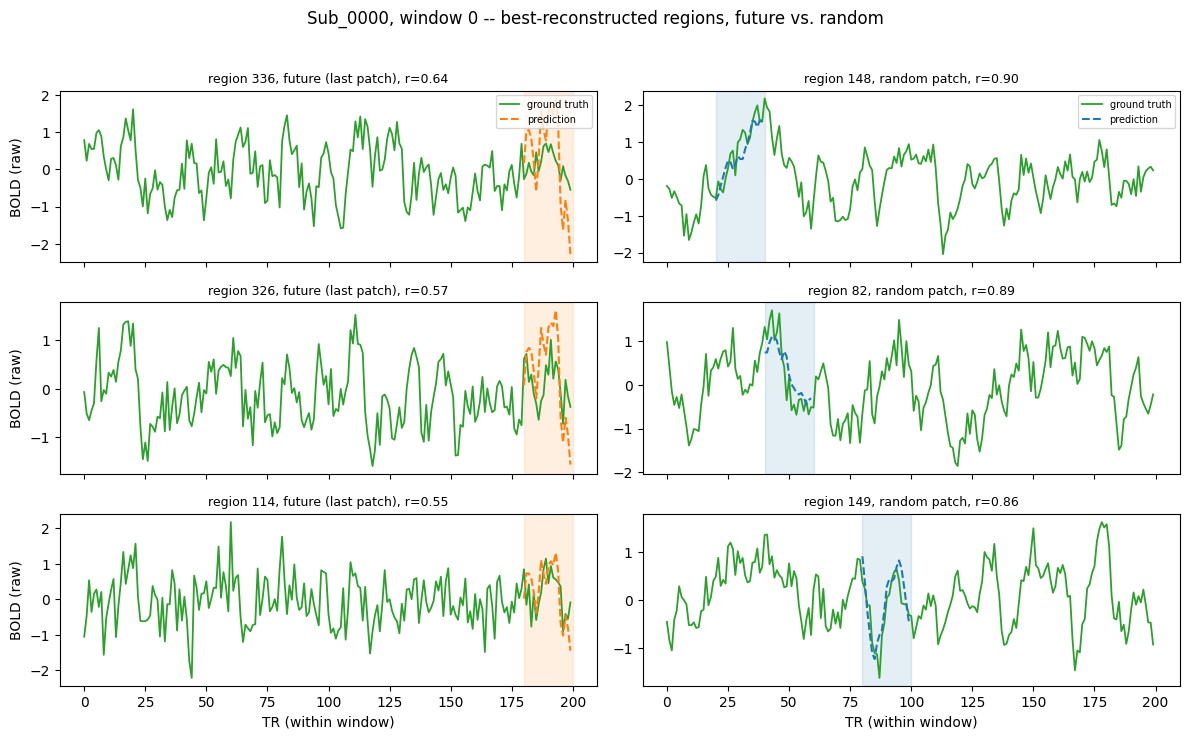

In [6]:
conditions = [
    ("future (last patch)", pred_future, patch_future, r_future, "tab:orange"),
    ("random patch", pred_random, patch_random, r_random, "tab:blue"),
]

top_regions_per_condition = [
    np.argsort(np.nan_to_num(r_vals, nan=-np.inf))[-N_EXAMPLES_PER_CONDITION:][::-1]
    for (_, _, _, r_vals, _) in conditions
]

fig, axes = plt.subplots(N_EXAMPLES_PER_CONDITION, 2, figsize=(12, 2.4 * N_EXAMPLES_PER_CONDITION), sharex=True)

for col, ((label, pred, patch_pos, r_vals, color), top_regions) in enumerate(zip(conditions, top_regions_per_condition)):
    for row, region in enumerate(top_regions):
        ax = axes[row, col]
        ax.plot(raw_window[region], color="tab:green", linewidth=1.3, label="ground truth")
        patch = patch_pos[region]
        tr_lo, tr_hi = patch * patch_size, (patch + 1) * patch_size
        ax.plot(range(tr_lo, tr_hi), pred[region, patch, :], color=color, linewidth=1.5,
                linestyle="--", label="prediction")
        ax.axvspan(tr_lo, tr_hi, color=color, alpha=0.12)
        ax.set_title(f"region {region}, {label}, r={r_vals[region]:.2f}", fontsize=9)
        if row == 0:
            ax.legend(fontsize=7, loc="upper right")
        if col == 0:
            ax.set_ylabel("BOLD (raw)")

axes[-1, 0].set_xlabel("TR (within window)")
axes[-1, 1].set_xlabel("TR (within window)")
fig.suptitle(f"{sub_id}, window {WINDOW_INDEX} -- best-reconstructed regions, future vs. random", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_w{WINDOW_INDEX}_future_vs_random_best_examples.png"), dpi=130, bbox_inches="tight")
plt.show()

### Distribution comparison (single subject, all regions)

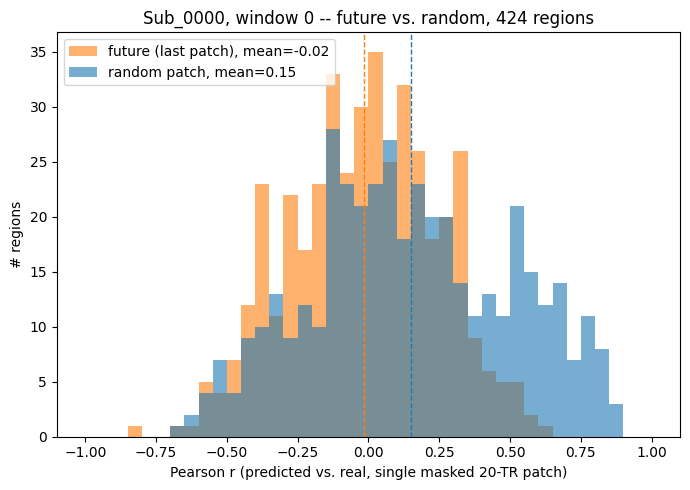

Paired Wilcoxon signed-rank (future vs. random, same regions, n=424): statistic=27711.0, p=6.534e-12


In [7]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
bins = np.linspace(-1, 1, 41)
ax.hist(r_future, bins=bins, alpha=0.6, color="tab:orange", label=f"future (last patch), mean={np.nanmean(r_future):.2f}")
ax.hist(r_random, bins=bins, alpha=0.6, color="tab:blue", label=f"random patch, mean={np.nanmean(r_random):.2f}")
ax.axvline(np.nanmean(r_future), color="tab:orange", linestyle="--", linewidth=1)
ax.axvline(np.nanmean(r_random), color="tab:blue", linestyle="--", linewidth=1)
ax.set_xlabel("Pearson r (predicted vs. real, single masked 20-TR patch)")
ax.set_ylabel("# regions")
ax.set_title(f"{sub_id}, window {WINDOW_INDEX} -- future vs. random, {num_regions} regions")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"{sub_id}_w{WINDOW_INDEX}_future_vs_random_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

valid = ~(np.isnan(r_future) | np.isnan(r_random))
stat, p = stats.wilcoxon(r_future[valid], r_random[valid])
print(f"Paired Wilcoxon signed-rank (future vs. random, same regions, n={int(valid.sum())}): statistic={stat:.1f}, p={p:.4g}")

## Multi-subject pooled comparison

Repeats the same single-pass, two-condition procedure for the first
`N_SUBJECTS_MULTI` subjects. The random condition's per-region patch positions are
re-drawn per subject (`RANDOM_SEED + subject_index`) so the pooled "random"
distribution isn't just `N_SUBJECTS_MULTI` copies of the same 424 patch choices.
Subjects with any NaN in their first `WINDOW_SIZE` TRs are skipped (same guard as
the single-subject cell above, for the same alignment reason).

In [8]:
multi_results = []  # rows: subject_id, region, condition, patch, tr_start, tr_end, r
skipped_subjects = []

for subject_index in range(N_SUBJECTS_MULTI):
    with h5py.File(INPUT_H5, "r") as f:
        sub_id_m = f["subject_ids"][subject_index].decode("utf-8")
        raw_data_m = f["parcel_ts"][subject_index, :, :]

    if np.isnan(raw_data_m[:WINDOW_SIZE, :]).any():
        skipped_subjects.append(sub_id_m)
        print(f"{sub_id_m}: skipped (NaNs in first {WINDOW_SIZE} TRs)")
        continue

    fmri_windows_m = preprocess_subject_data(raw_data_m, num_windows=NUM_WINDOWS, window_size=WINDOW_SIZE)
    x_m = fmri_windows_m[WINDOW_INDEX : WINDOW_INDEX + 1].to(device)
    raw_window_m = raw_data_m[:WINDOW_SIZE, :].T

    future_idx_m = [token_index(r, FUTURE_PATCH_IDX, num_patches) for r in range(num_regions)]
    rng_m = np.random.default_rng(RANDOM_SEED + subject_index)
    random_patch_m = rng_m.integers(0, num_patches, size=num_regions)
    random_idx_m = [token_index(r, int(p), num_patches) for r, p in enumerate(random_patch_m)]

    pred_future_m, mask_future_m = predict_exact_patches(model, x_m, spatial_coords, future_idx_m, num_regions, num_patches)
    pred_random_m, mask_random_m = predict_exact_patches(model, x_m, spatial_coords, random_idx_m, num_regions, num_patches)

    r_future_m, patch_future_m = per_region_patch_correlation(pred_future_m, mask_future_m, raw_window_m, patch_size)
    r_random_m, patch_random_m = per_region_patch_correlation(pred_random_m, mask_random_m, raw_window_m, patch_size)

    for region in range(num_regions):
        for condition, patch_arr, r_arr in [("future", patch_future_m, r_future_m), ("random", patch_random_m, r_random_m)]:
            patch = int(patch_arr[region])
            multi_results.append({
                "subject_id": sub_id_m, "region": region, "condition": condition,
                "patch": patch, "tr_start": patch * patch_size, "tr_end": (patch + 1) * patch_size,
                "r": float(r_arr[region]),
            })

    print(f"{sub_id_m}: future mean r={np.nanmean(r_future_m):.3f} | random mean r={np.nanmean(r_random_m):.3f}")

n_ok = N_SUBJECTS_MULTI - len(skipped_subjects)
print(f"\nDone: {n_ok} subjects processed, {len(skipped_subjects)} skipped ({skipped_subjects}).")

Sub_0000: future mean r=-0.016 | random mean r=0.151


Sub_0001: future mean r=-0.025 | random mean r=0.109


Sub_0002: future mean r=0.233 | random mean r=0.038


Sub_0004: future mean r=-0.042 | random mean r=0.251


Sub_0005: future mean r=0.166 | random mean r=0.045


...

Sub_0021: future mean r=0.136 | random mean r=0.258


Sub_0022: future mean r=0.005 | random mean r=0.268


Sub_0023: future mean r=-0.058 | random mean r=0.179


Sub_0024: future mean r=-0.193 | random mean r=0.117


Sub_0025: future mean r=0.070 | random mean r=0.177

Done: 25 subjects processed, 0 skipped ([]).


### Pooled distribution across all subjects

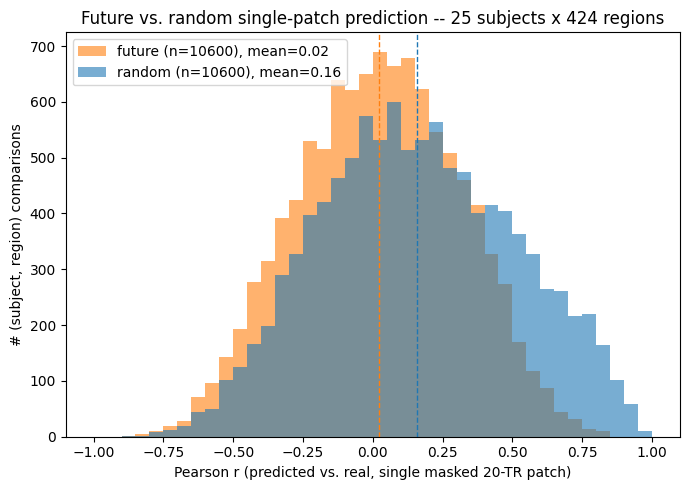

Pooled paired Wilcoxon (future vs. random, n=10600): statistic=19094878.0, p=2.2e-179
future: mean=0.022, median=0.026, std=0.291
random: mean=0.159, median=0.146, std=0.349
Saved 21200 rows -> outputs/future_vs_random_w0_correlations.csv


In [9]:
r_future_all = np.array([row["r"] for row in multi_results if row["condition"] == "future"])
r_random_all = np.array([row["r"] for row in multi_results if row["condition"] == "random"])

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
bins = np.linspace(-1, 1, 41)
ax.hist(r_future_all, bins=bins, alpha=0.6, color="tab:orange", label=f"future (n={len(r_future_all)}), mean={np.nanmean(r_future_all):.2f}")
ax.hist(r_random_all, bins=bins, alpha=0.6, color="tab:blue", label=f"random (n={len(r_random_all)}), mean={np.nanmean(r_random_all):.2f}")
ax.axvline(np.nanmean(r_future_all), color="tab:orange", linestyle="--", linewidth=1)
ax.axvline(np.nanmean(r_random_all), color="tab:blue", linestyle="--", linewidth=1)
ax.set_xlabel("Pearson r (predicted vs. real, single masked 20-TR patch)")
ax.set_ylabel("# (subject, region) comparisons")
ax.set_title(f"Future vs. random single-patch prediction -- {n_ok} subjects x {num_regions} regions")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"multi_subject_w{WINDOW_INDEX}_future_vs_random_distribution.png"), dpi=130, bbox_inches="tight")
plt.show()

valid_all = ~(np.isnan(r_future_all) | np.isnan(r_random_all))
stat_all, p_all = stats.wilcoxon(r_future_all[valid_all], r_random_all[valid_all])
print(f"Pooled paired Wilcoxon (future vs. random, n={int(valid_all.sum())}): statistic={stat_all:.1f}, p={p_all:.4g}")
print(f"future: mean={np.nanmean(r_future_all):.3f}, median={np.nanmedian(r_future_all):.3f}, std={np.nanstd(r_future_all):.3f}")
print(f"random: mean={np.nanmean(r_random_all):.3f}, median={np.nanmedian(r_random_all):.3f}, std={np.nanstd(r_random_all):.3f}")

csv_path = os.path.join(OUTPUTS_DIR, f"future_vs_random_w{WINDOW_INDEX}_correlations.csv")
with open(csv_path, "w", newline="") as f_out:
    writer = csv.DictWriter(f_out, fieldnames=["subject_id", "region", "condition", "patch", "tr_start", "tr_end", "r"])
    writer.writeheader()
    writer.writerows(multi_results)
print(f"Saved {len(multi_results)} rows -> {csv_path}")

### Per-subject breakdown: is the effect consistent across subjects?

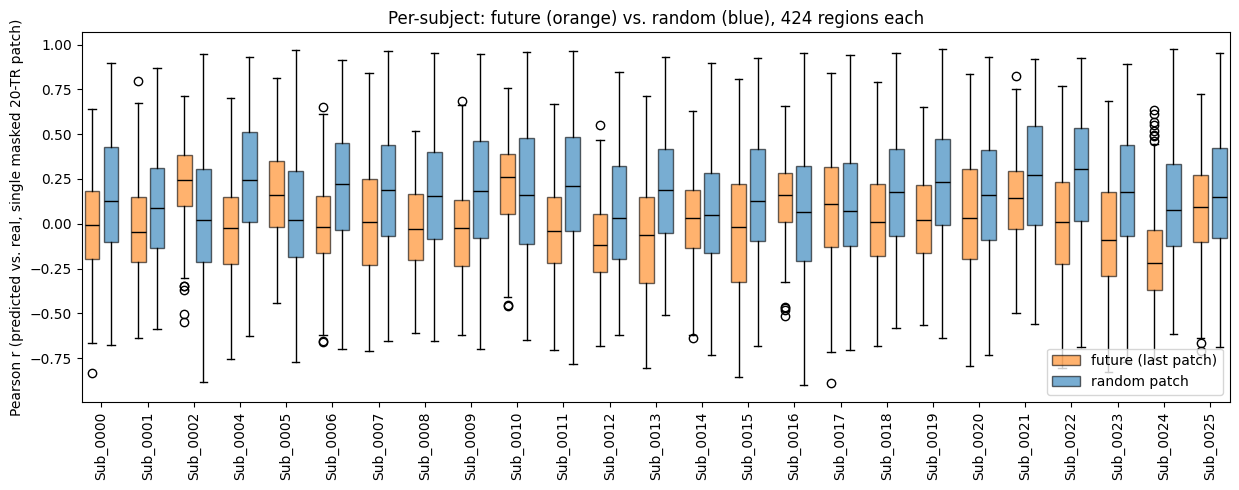

In [10]:
subject_order = list(dict.fromkeys(row["subject_id"] for row in multi_results))

future_by_subject = [[row["r"] for row in multi_results if row["subject_id"] == sid and row["condition"] == "future"]
                      for sid in subject_order]
random_by_subject = [[row["r"] for row in multi_results if row["subject_id"] == sid and row["condition"] == "random"]
                      for sid in subject_order]

positions_future = np.arange(len(subject_order)) * 2.2
positions_random = positions_future + 0.9

fig, ax = plt.subplots(1, 1, figsize=(max(10, len(subject_order) * 0.5), 5))
bp_f = ax.boxplot(future_by_subject, positions=positions_future, widths=0.7, patch_artist=True,
                   boxprops=dict(facecolor="tab:orange", alpha=0.6), medianprops=dict(color="black"))
bp_r = ax.boxplot(random_by_subject, positions=positions_random, widths=0.7, patch_artist=True,
                   boxprops=dict(facecolor="tab:blue", alpha=0.6), medianprops=dict(color="black"))
ax.set_xticks((positions_future + positions_random) / 2)
ax.set_xticklabels(subject_order, rotation=90)
ax.set_ylabel("Pearson r (predicted vs. real, single masked 20-TR patch)")
ax.set_title(f"Per-subject: future (orange) vs. random (blue), {num_regions} regions each")
ax.legend([bp_f["boxes"][0], bp_r["boxes"][0]], ["future (last patch)", "random patch"], loc="lower right")
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, f"multi_subject_w{WINDOW_INDEX}_future_vs_random_per_subject.png"), dpi=130, bbox_inches="tight")
plt.show()